# Stat - Descriptive Operations

This notebook documents the statistical operations available in the `stat` library.
It includes:
- Central Tendency (Mean, Median, Mode)
- Dispersion (Variance, Std Dev, SEM, MAD, IQR)
- Distribution Shape (Skewness, Kurtosis)
- Summary Statistics
- Data Grouping and Frequencies

---

## 1. Setup

We will use the `insurance` dataset for our examples.

In [12]:
import pandas as pd
import src.stat as stat

# Load the dataset
pd_df = pd.read_csv('../examples/assets/insurance.csv')

# Create a stat object
df = stat.represent(pd_df)
df.show('Insurance Dataset', max_rows=5)

                               Insurance Dataset                               
+-----------------------------------------------------------------------------+
| Index | age | sex    | bmi    | children | smoker | region    | charges     |
|-------+-----+--------+--------+----------+--------+-----------+-------------|
|     0 | 19  | female | 27.9   | 0        | yes    | southwest | 16884.924   |
|     1 | 18  | male   | 33.77  | 1        | no     | southeast | 1725.5523   |
|     2 | 28  | male   | 33.0   | 3        | no     | southeast | 4449.462    |
|     3 | 33  | male   | 22.705 | 0        | no     | northwest | 21984.47061 |
|     4 | 32  | male   | 28.88  | 0        | no     | northwest | 3866.8552   |
|   ... | ... | ...    | ...    | ...      | ...    | ...       | ...         |
+-----------------------------------------------------------------------------+

## 2. Central Tendency

Central tendency measures the center of the data distribution.

Mean Age: 39.20702541106129
Geometric Mean BMI: 30.052497910118962
Median Charges: 9382.033


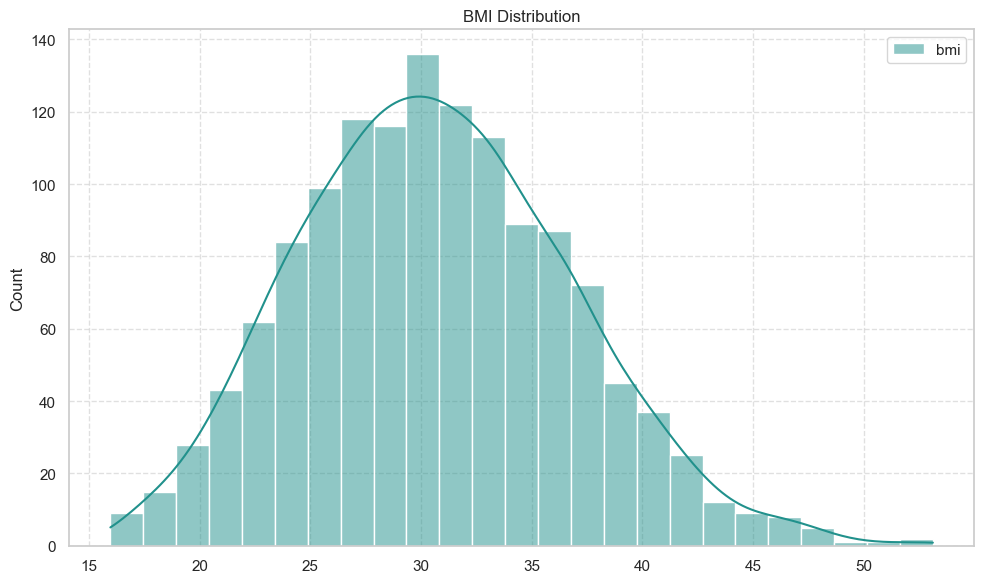

In [14]:
# Mean (Arithmetic, Geometric, Harmonic)
print("Mean Age:", df.mean(series='age'))
print("Geometric Mean BMI:", df.mean(method='geometric', series='bmi'))

# Median
print("Median Charges:", df.median(series='charges'))

# Visualizing the distribution of BMI
df.plot(columns='bmi', kind='hist', title='BMI Distribution')

## 3. Dispersion and Spread

These measures describe how spread out the data is.

Variance of BMI: 37.16008997478835
Std Dev of BMI: 6.0959076415894256
SEM of Charges: 331.0674543156824
MAD of Age: 12.247384155455904


C:\Users\aarin\PycharmProjects\Stat\src\stat\graphs\plotter.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x=x, y=y, hue=hue, palette=palette, ax=ax, **kwargs)


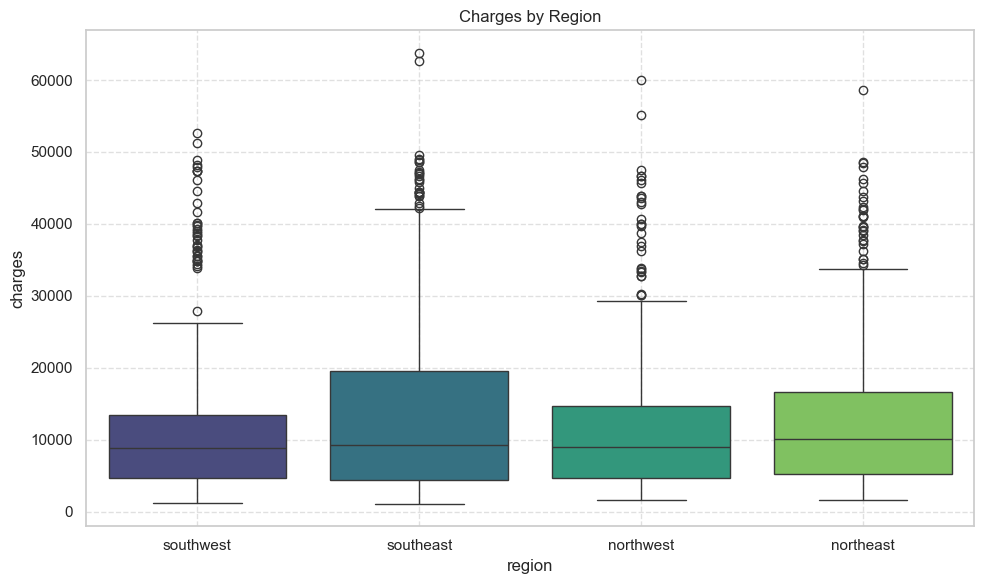

In [15]:
# Variance and Standard Deviation
print("Variance of BMI:", df.variance(series='bmi'))
print("Std Dev of BMI:", df.std(series='bmi'))

# Standard Error of Mean (SEM)
print("SEM of Charges:", df.sem(series='charges'))

# Mean Absolute Deviation (MAD)
print("MAD of Age:", df.mad(series='age'))

# Box plot to visualize spread
df.plot(columns=['region', 'charges'], kind='box', title='Charges by Region')

## 4. Percentiles and Quantiles

Quantiles and Percentiles help understand the relative position of values.

In [16]:
# 90th Percentile of charges
print("90th Percentile:", df.percentile(90, series='charges'))

# Interquartile Range (IQR)
print("IQR of BMI:", df.iqr(series='bmi'))

90th Percentile: 34831.7197
IQR of BMI: 8.3975


## 5. Distribution Shape

Skewness and Kurtosis describe the asymmetry and tailedness of the distribution.

In [17]:
# Skewness (is it leaning?)
print("Skewness of Charges:", df.skewness(series='charges'))

# Kurtosis (how fat are the tails?)
print("Kurtosis of Age:", df.kurtosis(series='age'))

Skewness of Charges: 1.5158796580240386
Kurtosis of Age: -1.2450876526418668


## 5.5 Basic Statistics and Correlation

Quick access to min, max, range, and correlations.

Min BMI: 15.96
Max BMI: 53.13
Range of BMI: 37.17


                                          Correlation Matrix                                          
+----------------------------------------------------------------------------------------------------+
|    Index | age                 | bmi                  | children             | charges             |
|----------+---------------------+----------------------+----------------------+---------------------|
|      age | 1.0                 | 0.1092718815485351   | 0.04246899855884958  | 0.299008193330648   |
|      bmi | 0.1092718815485351  | 1.0                  | 0.012758900820673994 | 0.19834096883362912 |
| children | 0.04246899855884958 | 0.012758900820673994 | 1.0                  | 0.06799822684790495 |
|  charges | 0.299008193330648   | 0.19834096883362912  | 0.06799822684790495  | 1.0                 |
+----------------------------------------------------------------------------------------------------+

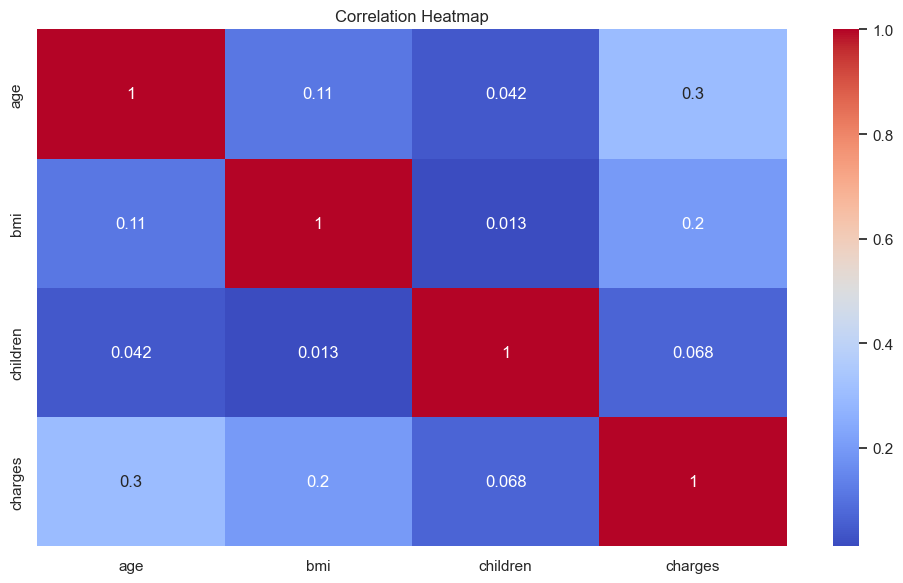

In [18]:
# Min, Max, Range
print("Min BMI:", df.min(series='bmi'))
print("Max BMI:", df.max(series='bmi'))
print("Range of BMI:", df.range(series='bmi'))

# Correlation matrix
df.filter_types('n').corr().show('Correlation Matrix')

# Correlation Heatmap
df.filter_types('n').plot(kind='heatmap', title='Correlation Heatmap')

## 6. Grouping and Categorical Data

Analyzing data by categories.

  Smoker Counts  
+---------------+
| Index | count |
|-------+-------|
|    no | 1064  |
|   yes | 274   |
+---------------+

                                      Mean stats by Region                                      
+----------------------------------------------------------------------------------------------+
|     Index | age               | bmi                | children           | charges            |
|-----------+-------------------+--------------------+--------------------+--------------------|
| northeast | 39.26851851851852 | 29.173503086419753 | 1.0462962962962963 | 13406.384516385804 |
| northwest | 39.19692307692308 | 29.199784615384615 | 1.1476923076923078 | 12417.575373969232 |
| southeast | 38.93956043956044 | 33.35598901098901  | 1.0494505494505495 | 14735.41143760989  |
| southwest | 39.45538461538462 | 30.596615384615383 | 1.1415384615384616 | 12346.937377292308 |
+----------------------------------------------------------------------------------------------+

C:\Users\aarin\PycharmProjects\Stat\src\stat\graphs\plotter.py:105: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x=x, hue=hue, palette=palette, ax=ax, **kwargs)


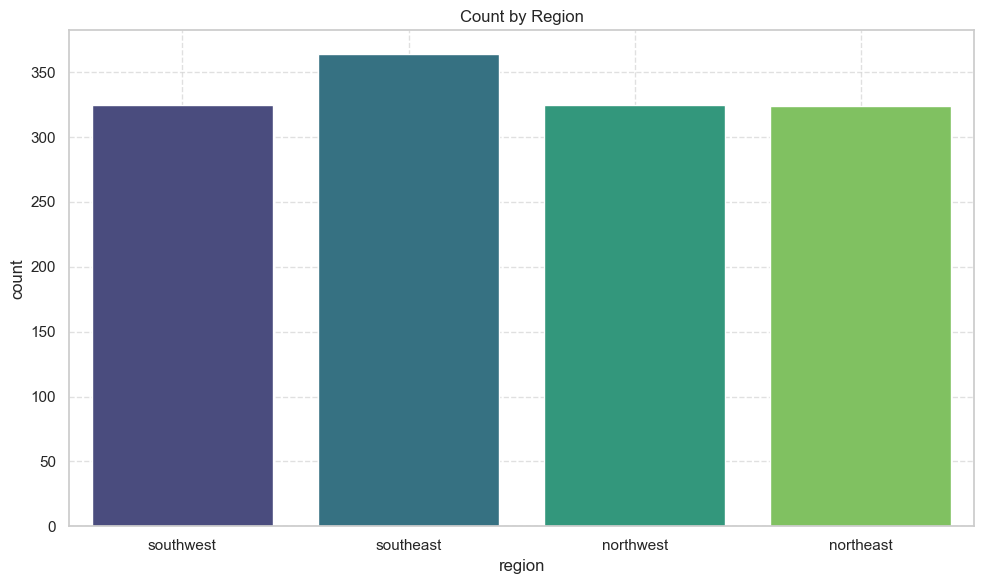

In [19]:
# Frequencies of smoker status
df.frequencies('smoker').show('Smoker Counts')

# Group by region and calculate mean of numeric columns
df.groupby(by='region', operation='mean').show('Mean stats by Region')

# Visualizing counts
df.plot(columns='region', kind='count', title='Count by Region')

## 7. Comprehensive Summary

The `summary()` method provides all major descriptive statistics at once.

In [20]:
# Summary of all numeric columns
df.summary().show('Full Descriptive Summary')

                                             Full Descriptive Summary                                              
+-----------------------------------------------------------------------------------------------------------------+
|       |       |       |      |       |      |       | skew | kurto |      |       |      |       |      |       |
| Index | mean  | med   | var  | std   | sem  | mad   | ness | sis   | 25%  | 75%   | iqr  | min   | max  | range |
|-------+-------+-------+------+-------+------+-------+------+-------+------+-------+------+-------+------+-------|
|   age | 39.20 | 39.0  | 197. | 14.04 | 0.38 | 12.24 | 0.05 | -1.24 | 27.0 | 51.0  | 24.0 | 18.0  | 64.0 | 46.0  |
|       | 70254 |       | 2538 | 47090 | 4102 | 73841 | 5672 | 50876 |      |       |      |       |      |       |
|       | 11061 |       | 5198 | 38954 | 4194 | 55455 | 5156 | 52641 |      |       |      |       |      |       |
|       | 29    |       | 8890 | 522   | 8323 | 904   | 5299 | 8668  |      |       |      |       |      |       |
|       |       |       | 9    |       | 204  |       | 184  |       |      |       |      |       |      |       |
|   bmi | 30.66 | 30.4  | 37.1 | 6.095 | 0.16 | 4.892 | 0.28 | -0.05 | 26.2 | 34.69 | 8.39 | 15.96 | 53.1 | 37.17 |
|       | 33968 |       | 6008 | 90764 | 6714 | 53736 | 4047 | 07315 | 9625 | 375   | 75   |       | 3    |       |
|       | 60986 |       | 9974 | 15894 | 2315 | 92077 | 1105 | 31354 |      |       |      |       |      |       |
|       | 55    |       | 7883 | 256   | 0074 | 73    | 9874 | 6777  |      |       |      |       |      |       |
|       |       |       | 5    |       | 15   |       | 477  |       |      |       |      |       |      |       |
| chil… | 1.094 | 1.0   | 1.45 | 1.205 | 0.03 | 0.952 | 0.93 | 0.202 | 0.0  | 2.0   | 2.0  | 0.0   | 5.0  | 5.0   |
|       | 91778 |       | 2126 | 04217 | 2956 | 91479 | 8380 | 45414 |      |       |      |       |      |       |
|       | 77429 |       | 6374 | 24928 | 1554 | 82062 | 4401 | 67168 |      |       |      |       |      |       |
|       |       |       | 8628 | 497   | 2835 | 78    | 7024 | 896   |      |       |      |       |      |       |
|       |       |       | 7    |       | 6865 |       | 15   |       |      |       |      |       |      |       |
| char… | 13270 | 9382. | 1465 | 12105 | 331. | 8351. | 1.51 | 1.606 | 4740 | 16639 | 1189 | 1121. | 6377 | 62648 |
|       | .4222 | 033   | 4276 | .4849 | 0674 | 03963 | 5879 | 29865 | .287 | .9125 | 9.62 | 8739  | 0.42 | .5541 |
|       | 65141 |       | 6.49 | 75561 | 5431 | 06584 | 6580 | 32967 | 15   | 15    | 5365 |       | 801  | 10000 |
|       | 257   |       | 3547 | 612   | 5682 | 46    | 2403 | 916   |      |       |      |       |      | 005   |
|       |       |       | 92   |       | 4    |       | 86   |       |      |       |      |       |      |       |
+-----------------------------------------------------------------------------------------------------------------+